In [21]:
import datasets

import os
os.environ["HF_HUB_ENABLE_HF_TRANSFER"] = "1"

dataset = datasets.load_dataset("sayakpaul/pickapic_v2_webdataset")

Repo card metadata block was not found. Setting CardData to empty.


In [22]:
len(dataset['train'])

959040

In [25]:
from collections import Counter
Counter(dataset['train']['label_0.txt'])

Counter({'1.0': 543015, '0.0': 308278, '0.5': 107747})

In [4]:
dataset

DatasetDict({
    train: Dataset({
        features: ['jpg_0.jpg', 'jpg_1.jpg', 'label_0.txt', 'label_1.txt', 'original_prompt.txt', '__key__', '__url__'],
        num_rows: 959040
    })
})

In [36]:
dataset['train'][950000]

{'jpg_0.jpg': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=768x768>,
 'jpg_1.jpg': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=768x768>,
 'label_0.txt': '0.5',
 'label_1.txt': '0.5',
 'original_prompt.txt': 'Goat monster',
 '__key__': '1362',
 '__url__': '/home/dkp45/.cache/huggingface/hub/datasets--sayakpaul--pickapic_v2_webdataset/snapshots/ad9594597d075e1915356a1e52a3199cb10ddeef/00638.tar'}

In [ ]:
from PIL import Image
import io
import concurrent
import json
from tqdm import tqdm

def process_example(args):
    idx, example, save_dir = args
    caption = example["original_prompt.txt"]
    jpg_0 = example["jpg_0.jpg"]
    jpg_1 = example["jpg_1.jpg"]
    label_0 = example["label_0.txt"]
    label_1 = example["label_1.txt"]

    refer_id = label_1

    image_0_basename = f"{idx:06d}_0.jpg"
    image_1_basename = f"{idx:06d}_1.jpg"

    image_0_path = os.path.join(save_dir, image_0_basename)
    image_1_path = os.path.join(save_dir, image_1_basename)
    jpg_0.save(image_0_path)
    jpg_1.save(image_1_path)
    return {
        "caption": caption,
        "image_0_basename": image_0_basename,
        "image_1_basename": image_1_basename,
        "refer_id": refer_id,
    }

res = []
save_dir = 'alignment/datasets/pickapic_v2'
# Make sure local save dir for this split exists
if not os.path.exists(save_dir):
    os.makedirs(save_dir, exist_ok=True)

# Prepare argument tuples
args_iter = ((idx, example, save_dir) for idx, example in enumerate(dataset['train']))

max_workers = min(32, os.cpu_count() or 1)

with concurrent.futures.ThreadPoolExecutor(max_workers=max_workers) as executor:
    for out in tqdm(executor.map(process_example, args_iter, chunksize=32), 
                   total=len(dataset['train']), 
                   desc="Processing examples"):
        res.append(out)

with open("alignment/datasets/manifest/pickapic_v2.json", "w") as f:
    json.dump(res, f)

In [13]:
dataset['train'][:10]['label_1.txt']

['0.0', '0.0', '1.0', '1.0', '0.5', '1.0', '0.0', '0.0', '0.0', '0.5']

In [14]:
dataset['train'][:10]['label_0.txt']

['1.0', '1.0', '0.0', '0.0', '0.5', '0.0', '1.0', '1.0', '1.0', '0.5']

(np.float64(-0.5), np.float64(767.5), np.float64(767.5), np.float64(-0.5))

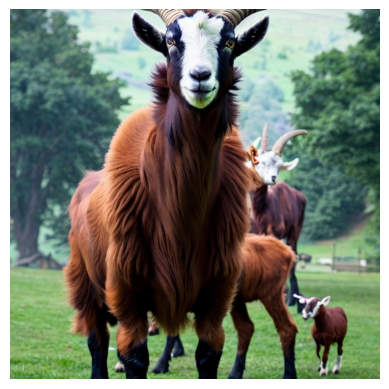

In [37]:
import matplotlib.pyplot as plt
plt.imshow(dataset['train'][950000]['jpg_0.jpg'])
plt.axis('off')

(np.float64(-0.5), np.float64(767.5), np.float64(767.5), np.float64(-0.5))

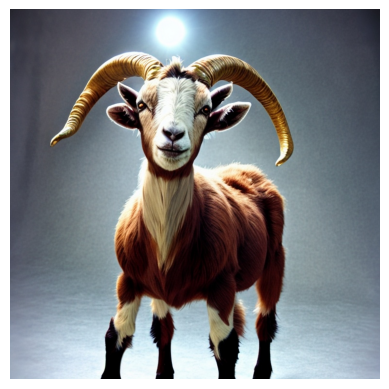

In [38]:
plt.imshow(dataset['train'][950000]['jpg_1.jpg'])
plt.axis('off')

In [41]:
dataset['train'][:10]

{'jpg_0.jpg': [<PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=768x768>,
  <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=768x768>,
  <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=768x768>,
  <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=512x512>,
  <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=768x768>,
  <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=768x768>,
  <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=512x512>,
  <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=768x768>,
  <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=768x768>,
  <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=768x768>],
 'jpg_1.jpg': [<PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=512x512>,
  <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=768x768>,
  <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=512x512>,
  <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=768x768>,
  <PIL.JpegImagePlugin.JpegImageFil

In [20]:
from datasets.utils.file_utils import cached_path

cache_path = cached_path("sayakpaul/pickapic_v2_webdataset")
cache_path


FileNotFoundError: Local file /home/dkp45/dr-dpo/sayakpaul/pickapic_v2_webdataset doesn't exist